# FT-Transformer

## Что такое FT-Transformer?

**FT-Transformer** (Feature Tokenizer + Transformer, Gorishniy et al., NeurIPS 2021) — архитектура на основе Transformer, адаптированная специально для **табличных данных**. Ключевая идея: каждый признак превращается в вектор фиксированной размерности (`d_token`) — токен — а затем все токены обрабатываются механизмом **self-attention**, что позволяет фиксировать произвольные попарные взаимодействия между признаками.

### Ключевые компоненты

#### 1. Feature Tokenizer — токенизация признаков

Каждый признак превращается в вектор размерности `d_token`:

- **Числовой** $x_i$ → $\mathbf{W}_i \, x_i + \mathbf{b}_i$ — **отдельная** линейная проекция для каждого признака (не общая матрица!)
- **Категориальный** → отдельная таблица эмбеддингов `(n_categories, d_token)`

В результате получаем матрицу токенов $T \in \mathbb{R}^{n\_features \times d\_token}$.

Принципиальное отличие от обычной FC-сети: вместо одной матрицы весов для всех числовых признаков сразу — **своя матрица для каждого**. Это позволяет модели различать признаки уже на уровне эмбеддинга, до применения внимания.

#### 2. [CLS]-токен

Перед последовательностью токенов-признаков добавляется обучаемый вектор `[CLS]` (аналогично BERT).  
После прохождения через Transformer выход именно этого токена используется для итогового предсказания.

#### 3. Transformer-блоки (Pre-LN архитектура)

Последовательность из `n_blocks` одинаковых блоков:

```
LayerNorm → Multi-Head Self-Attention → Residual + Dropout
LayerNorm → FFN(ReGLU) → Residual + Dropout
```

- **Pre-LN** (нормализация перед блоком, а не после) стабилизирует обучение без warm-up
- **Multi-Head Self-Attention**: каждый токен-признак может «смотреть» на все остальные признаки — так модель улавливает взаимодействия типа «расстояние до метро × наличие метро поблизости»
- **ReGLU-активация** в FFN: $\text{FFN}(\mathbf{x}) = (\mathbf{W}_1 \mathbf{x}) \odot \text{ReLU}(\mathbf{W}_2 \mathbf{x})$ — gating механизм, фильтрующий нерелевантную информацию

#### 4. Предсказание

$$\hat{y} = \text{Linear}(\text{ReLU}(\text{LayerNorm}(\mathbf{x}_{\text{CLS}})))$$

### Ключевые гиперпараметры

| Параметр | Описание | Дефолт (статья) |
|---|---|---|
| `d_token` | Размерность каждого токена | 192 |
| `n_blocks` | Число Transformer-блоков | 3 |
| `attention_n_heads` | Число голов самовнимания | 8 |
| `attention_dropout` | Dropout в attention | 0.2 |
| `ffn_d_hidden` | Размер скрытого слоя FFN | 256 (≈ 4/3 × d_token) |
| `ffn_dropout` | Dropout в FFN | 0.1 |
| `residual_dropout` | Dropout на residual-связях | 0.0 |


*Gorishniy et al., "Revisiting Deep Learning Models for Tabular Data", NeurIPS 2021, arXiv:2106.11959*

## 1. Импорты и конфигурация

In [26]:
import copy
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import rtdl

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import optuna
from tqdm.auto import tqdm
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_PATH  = Path("../../data/train_data_v2.csv")
MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(exist_ok=True)

torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device  : {DEVICE}", f"({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else "")

Device  : cuda (NVIDIA GeForce RTX 5080)


## 2. Загрузка данных и группировка признаков

In [11]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк × {df.shape[1]} колонок')
print(f'Таргет: min={df["target"].min():.4f}  max={df["target"].max():.4f}  mean={df["target"].mean():.4f}  std={df["target"].std():.4f}')

Датасет: 6200 строк × 134 колонок
Таргет: min=-0.1450  max=0.2186  mean=0.0008  std=0.0859


In [12]:
# Группы признаков
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
    'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
CONT_COLS = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]

print(f'Всего признаков : {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Всего признаков : 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 3. Препроцессинг

**Особенности препроцессинга для FT-Transformer:**
- Числовые признаки: `median` imputation → log1p для расстояний → `StandardScaler` → `float32` тензор
- Категориальные признаки: `OrdinalEncoder` → **`int64` тензор** (не float32 — это индексы эмбеддингов!)
- Признаки **не конкатенируются** в один массив: FT-Transformer принимает их раздельно как `(x_num, x_cat)`
- `cat_cardinalities` = число уникальных значений +1 (резерв для unknown при инференсе)

**Разбивка train / val / test = 70% / 15% / 15%** — идентично TabNet для корректного сравнения.  
Early stopping и Optuna оптимизируют по **val**, финальные метрики считаются **один раз на test**.

In [13]:
X = df[ALL_FEATURES].copy()
y = df['target'].values.astype(np.float32)

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

strat_col = df['city_size_category'].fillna('unknown')

# Отделяем test (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
# Из оставшихся отделяем val (~15% от всего)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

# Числовые: imputer → log1p для расстояний → scaler
imp_cont = SimpleImputer(strategy='median')
scaler = StandardScaler()

def process_cont(X_df, fit=False):
    vals = X_df[CONT_COLS].copy().astype(float)
    for c in DISTANCE_FEATURES:
        if c in vals.columns:
            vals[c] = np.log1p(vals[c].clip(lower=0))
    if fit:
        imp_cont.fit(vals)
        scaler.fit(imp_cont.transform(vals))
    return scaler.transform(imp_cont.transform(vals)).astype(np.float32)

# Категориальные: fillna → OrdinalEncoder → int64
enc_cat = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32,
)

def process_cat(X_df, fit=False):
    vals = X_df[CATEGORICAL_FEATURES].fillna('unknown').astype(str)
    if fit:
        enc_cat.fit(vals)
    encoded = enc_cat.transform(vals)
    for j in range(encoded.shape[1]):
        n_known = len(enc_cat.categories_[j])
        encoded[:, j] = np.where(encoded[:, j] < 0, float(n_known), encoded[:, j])
    return encoded.astype(np.int64)

# Fit только на train
process_cont(X_train, fit=True)
process_cat(X_train, fit=True)

X_train_num = process_cont(X_train)
X_train_cat = process_cat(X_train)
X_val_num   = process_cont(X_val)
X_val_cat   = process_cat(X_val)
X_test_num  = process_cont(X_test)
X_test_cat  = process_cat(X_test)

X_tv_num = np.vstack([X_train_num, X_val_num])
X_tv_cat = np.vstack([X_train_cat, X_val_cat])
y_tv = np.concatenate([y_train, y_val])

n_num = X_train_num.shape[1]
cat_cardinalities = [len(enc_cat.categories_[j]) + 1 for j in range(len(CATEGORICAL_FEATURES))]

def to_tensors(X_num, X_cat, y=None):
    num_t = torch.tensor(X_num, dtype=torch.float32).to(DEVICE)
    cat_t = torch.tensor(X_cat, dtype=torch.long).to(DEVICE)
    if y is not None:
        y_t = torch.tensor(y, dtype=torch.float32).to(DEVICE)
        return num_t, cat_t, y_t
    return num_t, cat_t

Xtr_num_t, Xtr_cat_t, ytr_t = to_tensors(X_train_num, X_train_cat, y_train)
Xvl_num_t, Xvl_cat_t, yvl_t = to_tensors(X_val_num,   X_val_cat,   y_val)
Xte_num_t, Xte_cat_t, yte_t = to_tensors(X_test_num,  X_test_cat,  y_test)
Xtv_num_t, Xtv_cat_t, ytv_t = to_tensors(X_tv_num,    X_tv_cat,    y_tv)

print(f'Train : {X_train_num.shape}  |  Val : {X_val_num.shape}  |  Test : {X_test_num.shape}')
print(f'n_num = {n_num},  cat_cardinalities = {cat_cardinalities}')

Train : (4339, 63)  |  Val : (931, 63)  |  Test : (930, 63)
n_num = 63,  cat_cardinalities = [9, 6, 5, 8]


## 4. Вспомогательные функции

In [14]:
def build_fttransformer(
    d_token=192, n_blocks=3,
    attention_dropout=0.2, ffn_d_hidden=256,
    ffn_dropout=0.1, residual_dropout=0.0,
):
    # make_baseline фиксирует "бумажные" дефолты:
    # attention_n_heads=8, ffn_activation='ReGLU', prenormalization=True,
    # attention/ffn normalization=LayerNorm, initialization='kaiming'
    return rtdl.FTTransformer.make_baseline(
        n_num_features=n_num,
        cat_cardinalities=cat_cardinalities,
        d_token=d_token,
        n_blocks=n_blocks,
        attention_dropout=attention_dropout,
        ffn_d_hidden=ffn_d_hidden,
        ffn_dropout=ffn_dropout,
        residual_dropout=residual_dropout,
        d_out=1,
    ).to(DEVICE)


def train_model(
    model, Xtr_num, Xtr_cat, ytr,
    Xvl_num, Xvl_cat, yvl,
    lr=1e-4, weight_decay=1e-5,
    max_epochs=300, patience=30, batch_size=256,
    show_progress=True,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    dataset = TensorDataset(Xtr_num, Xtr_cat, ytr)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    best_val_rmse = float('inf')
    best_state    = None
    patience_ctr  = 0
    history = {'train_loss': [], 'val_rmse': []}

    t0   = time.perf_counter()
    pbar = tqdm(range(max_epochs), desc='Training', unit='epoch', disable=not show_progress)

    for epoch in pbar:
        model.train()
        losses = []
        for xn, xc, yb in loader:
            optimizer.zero_grad()
            pred = model(xn, xc).squeeze(1)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())
        scheduler.step()

        epoch_loss = float(np.mean(losses))

        model.eval()
        with torch.no_grad():
            vl_pred = model(Xvl_num, Xvl_cat).squeeze(1)
            vl_rmse = float(torch.sqrt(F.mse_loss(vl_pred, yvl)))

        history['train_loss'].append(epoch_loss)
        history['val_rmse'].append(vl_rmse)

        if vl_rmse < best_val_rmse:
            best_val_rmse = vl_rmse
            best_state    = copy.deepcopy(model.state_dict())
            patience_ctr  = 0
        else:
            patience_ctr += 1

        pbar.set_postfix({
            'loss': f'{epoch_loss:.5f}',
            'val_rmse': f'{vl_rmse:.5f}',
            'best': f'{best_val_rmse:.5f}',
            'patience': f'{patience_ctr}/{patience}',
        })

        if patience_ctr >= patience:
            best_ep = int(np.argmin(history['val_rmse'])) + 1
            pbar.write(f'Early stopping at epoch {epoch+1}, best epoch = {best_ep}, best val_rmse = {best_val_rmse:.5f}')
            break

    model.load_state_dict(best_state)
    return model, time.perf_counter() - t0, history


def predict(model, X_num, X_cat):
    model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        pred = model(X_num, X_cat).squeeze(1).cpu().numpy()
    return pred, time.perf_counter() - t0


def report_metrics(model_name, model, fit_time):
    y_tr = ytr_t.cpu().numpy()
    y_te = yte_t.cpu().numpy()

    pred_train, t_tr = predict(model, Xtr_num_t, Xtr_cat_t)
    pred_test,  t_te = predict(model, Xte_num_t, Xte_cat_t)

    def _m(yt, yp):
        return {
            'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
            'MAE' : round(float(mean_absolute_error(yt, yp)), 4),
            'R²'  : round(float(r2_score(yt, yp)), 4),
        }

    tr_m = _m(y_tr, pred_train)
    te_m = _m(y_te, pred_test)

    table = pd.DataFrame([
        {'Split': 'Train', **tr_m, 'Fit time, s': round(fit_time, 2), 'Predict time, s': round(t_tr, 4)},
        {'Split': 'Test',  **te_m, 'Fit time, s': float('nan'),       'Predict time, s': round(t_te, 4)},
    ]).set_index('Split')

    print(f'\n{model_name}')
    display(
        table.style
        .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
                 'Fit time, s': lambda v: f'{v:.2f}' if not np.isnan(v) else '-',
                 'Predict time, s': '{:.4f}'})
        .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
        .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R²'])
    )

    return {
        'Model': model_name, **te_m, 'Fit time, s': round(fit_time, 2),
    }, pred_test


def plot_loss(history, title):
    train_loss = history['train_loss']
    val_rmse   = history['val_rmse']
    epochs     = range(1, len(train_loss) + 1)
    best_ep    = int(np.argmin(val_rmse)) + 1

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, train_loss, color='#3498db', label='Train MSE loss', linewidth=1.8)
    ax.plot(epochs, val_rmse,   color='#e74c3c', label='Val RMSE',       linewidth=1.8)
    ax.axvline(best_ep, color='#e67e22', linestyle='--', alpha=0.8,
               label=f'Best epoch={best_ep} (RMSE={min(val_rmse):.4f})')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Loss / RMSE')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Эксперимент 1 - Базовый FT-Transformer

Гиперпараметры по умолчанию из оригинальной статьи:
- `d_token = 192` — размерность каждого токена-признака
- `n_blocks = 3` — три Transformer-блока
- `attention_dropout = 0.2` / `ffn_dropout = 0.1` / `residual_dropout = 0.0`
- `ffn_d_hidden = 256` ≈ 4/3 × d_token (рекомендация из статьи)
- Оптимизатор: **AdamW**, `lr=1e-4`, `weight_decay=1e-5`
- Планировщик: **CosineAnnealingLR** (T_max = max_epochs)
- Batch size: 256, max epochs: 300, patience: 30

In [15]:
model_base = build_fttransformer(
    d_token=192, n_blocks=3,
    attention_dropout=0.2, ffn_d_hidden=256,
    ffn_dropout=0.1, residual_dropout=0.0,
)
n_params = sum(p.numel() for p in model_base.parameters() if p.requires_grad)
print(f'Параметров: {n_params:,}')

model_base, fit_time_base, history_base = train_model(
    model_base,
    Xtr_num_t, Xtr_cat_t, ytr_t,
    Xvl_num_t, Xvl_cat_t, yvl_t,
    lr=1e-4, weight_decay=1e-5,
    max_epochs=300, patience=30, batch_size=256, show_progress=True,
)

Параметров: 922,177


Training:  28%|██▊       | 84/300 [00:21<00:56,  3.86epoch/s, loss=0.00197, val_rmse=0.04956, best=0.04687, patience=30/30]

Early stopping at epoch 85, best epoch = 55, best val_rmse = 0.04687



FT-Transformer — Базовый


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0447,0.0352,0.7305,21.78,0.0985
Test,0.0475,0.0379,0.6973,-,0.0161


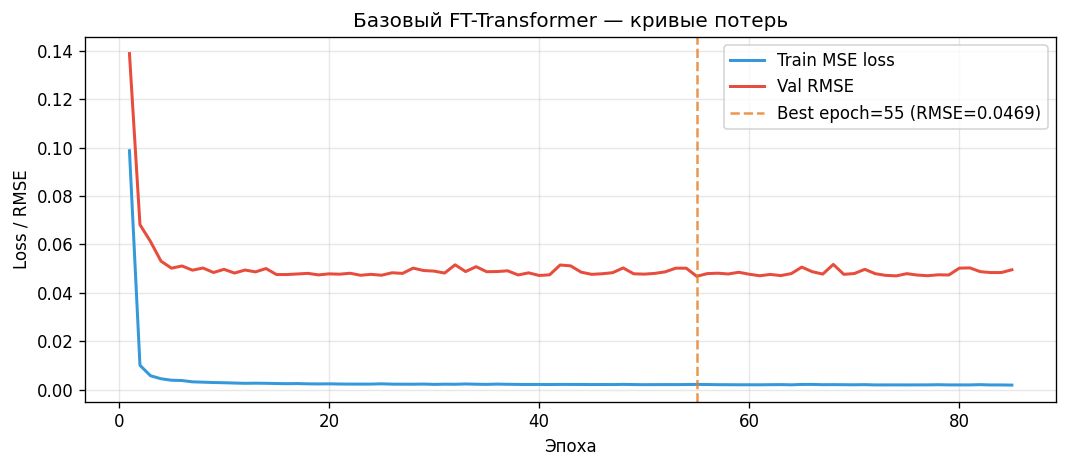

In [16]:
row_base, pred_base = report_metrics('FT-Transformer — Базовый', model_base, fit_time_base)
plot_loss(history_base, 'Базовый FT-Transformer — кривые потерь')

In [17]:
base_hyperparams = {
    'd_token': 192, 'n_blocks': 3,
    'attention_dropout': 0.2, 'ffn_d_hidden': 256,
    'ffn_dropout': 0.1, 'residual_dropout': 0.0,
    'lr': 1e-4, 'weight_decay': 1e-5,
}

save_path_base = MODELS_DIR / 'fttransformer_base.pt'
torch.save({
    'model_state_dict':  model_base.state_dict(),
    'hyperparams':       base_hyperparams,
    'ffn_d_hidden':      base_hyperparams['ffn_d_hidden'],
    'n_num':             n_num,
    'cat_cardinalities': cat_cardinalities,
    'feat_names':        CONT_COLS + CATEGORICAL_FEATURES,
}, save_path_base)
print(f'Модель сохранена: {save_path_base}')

Модель сохранена: ..\..\models\fttransformer_base.pt


## 6. Важность признаков - Permutation Importance

В отличие от TabNet с встроенными масками внимания, FT-Transformer не предоставляет интерпретируемость «из коробки».  
Используем **Permutation Importance** — модельно-независимый метод:

1. Считаем baseline RMSE на тестовой выборке с исходными данными
2. Для каждого признака: случайно перемешиваем его значения (разрушаем связь с таргетом)
3. Важность = RMSE_perm − RMSE_baseline

Чем больше прирост ошибки — тем важнее признак. Метод работает для любой модели без доступа к её весам.

Считаем permutation importance на тестовой выборке (5 повторений)...


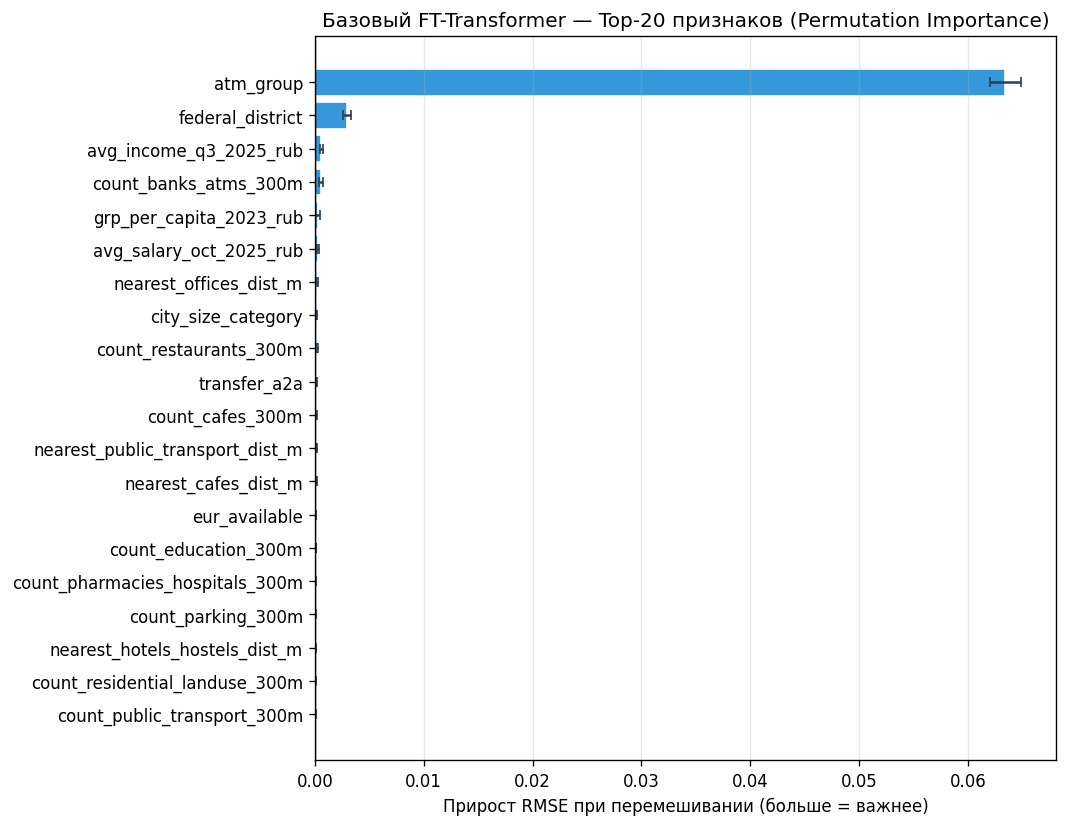


Top-10 признаков:


,Feature,Importance,Std
0,atm_group,0.0634,0.0014
1,federal_district,0.0030,0.0004
2,avg_income_q3_2025_rub,0.0006,0.0001
3,count_banks_atms_300m,0.0006,0.0001
4,grp_per_capita_2023_rub,0.0003,0.0002
5,avg_salary_oct_2025_rub,0.0003,0.0001
6,nearest_offices_dist_m,0.0002,0.0001
7,city_size_category,0.0002,0.0001
8,count_restaurants_300m,0.0002,0.0001
9,transfer_a2a,0.0001,0.0001


In [18]:
def permutation_importance_ft(
    model, X_num, X_cat, y_true,
    feat_names_num, feat_names_cat,
    n_repeats=5,
):
    model.eval()
    y_np = y_true.cpu().numpy()

    with torch.no_grad():
        baseline_pred = model(X_num, X_cat).squeeze(1).cpu().numpy()
    baseline_rmse = np.sqrt(mean_squared_error(y_np, baseline_pred))

    all_names  = feat_names_num + feat_names_cat
    n_num_feat = len(feat_names_num)
    n_cat_feat = len(feat_names_cat)
    importances = np.zeros((len(all_names), n_repeats))

    for rep in range(n_repeats):
        # Числовые признаки
        for i in range(n_num_feat):
            X_num_p = X_num.clone()
            perm = torch.randperm(X_num_p.shape[0])
            X_num_p[:, i] = X_num_p[perm, i]
            with torch.no_grad():
                p = model(X_num_p, X_cat).squeeze(1).cpu().numpy()
            importances[i, rep] = np.sqrt(mean_squared_error(y_np, p)) - baseline_rmse

        # Категориальные признаки
        for j in range(n_cat_feat):
            X_cat_p = X_cat.clone()
            perm = torch.randperm(X_cat_p.shape[0])
            X_cat_p[:, j] = X_cat_p[perm, j]
            with torch.no_grad():
                p = model(X_num, X_cat_p).squeeze(1).cpu().numpy()
            importances[n_num_feat + j, rep] = np.sqrt(mean_squared_error(y_np, p)) - baseline_rmse

    imp_df = pd.DataFrame({
        'Feature':    all_names,
        'Importance': importances.mean(axis=1),
        'Std':        importances.std(axis=1),
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    return imp_df


def plot_permutation_importance(imp_df, title, top_n=20):
    top = imp_df.head(top_n)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(
        top['Feature'][::-1], top['Importance'][::-1],
        xerr=top['Std'][::-1],
        color='#3498db', ecolor='#2c3e50', capsize=3, edgecolor='white',
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Прирост RMSE при перемешивании (больше = важнее)')
    ax.set_title(f'{title} — Top-{top_n} признаков (Permutation Importance)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Считаем permutation importance на тестовой выборке (5 повторений)...')
imp_base = permutation_importance_ft(
    model_base,
    Xte_num_t, Xte_cat_t, yte_t,
    CONT_COLS, CATEGORICAL_FEATURES,
    n_repeats=5,
)
plot_permutation_importance(imp_base, 'Базовый FT-Transformer')
print('\nTop-10 признаков:')
display(imp_base.head(10))

## 7. Эксперимент 2 - Подбор гиперпараметров (Optuna)

Пространство поиска охватывает ключевые гиперпараметры FT-Transformer:
- `d_token`: {96, 128, 192, 256} — ширина токена
- `n_blocks`: 1–6 — глубина трансформера
- `attention_dropout`: 0.0–0.4 — регуляризация внимания
- `ffn_d_hidden_factor`: 1.0–4.0 — множитель ширины FFN (`ffn_d_hidden = d_token × factor`)
- `ffn_dropout`: 0.0–0.3 — регуляризация FFN
- `residual_dropout`: 0.0–0.2 — регуляризация residual-связей
- `lr`: 5e-5–5e-3 (log-scale) — скорость обучения AdamW
- `weight_decay`: 1e-6–1e-3 (log-scale) — L2-регуляризация весов

In [19]:
def objective(trial):
    # d_token должен делиться на 8 (attention_n_heads=8 зафиксировано в make_baseline)
    d_token = trial.suggest_categorical('d_token', [96, 128, 192, 256])
    n_blocks = trial.suggest_int('n_blocks', 1, 6)
    att_drop = trial.suggest_float('attention_dropout', 0.0, 0.4)
    ffn_factor = trial.suggest_float('ffn_d_hidden_factor', 1.0, 4.0)
    ffn_drop = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    res_drop = trial.suggest_float('residual_dropout', 0.0, 0.2)
    lr = trial.suggest_float('lr', 5e-5, 5e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    ffn_d_hidden = int(d_token * ffn_factor)

    model = build_fttransformer(
        d_token=d_token, n_blocks=n_blocks,
        attention_dropout=att_drop, ffn_d_hidden=ffn_d_hidden,
        ffn_dropout=ffn_drop, residual_dropout=res_drop,
    )

    _, _, history = train_model(
        model,
        Xtr_num_t, Xtr_cat_t, ytr_t,
        Xvl_num_t, Xvl_cat_t, yvl_t,
        lr=lr, weight_decay=wd,
        max_epochs=300, patience=30, batch_size=256, show_progress=False,
    )

    return float(min(history['val_rmse']))


study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='fttransformer_tuning',
)
print('Запускаем Optuna (30 trials)...')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nЛучший RMSE (val) : {study.best_value:.4f}')
print(f'Лучшие params     : {study.best_params}')

Запускаем Optuna (30 trials)...


Best trial: 0. Best value: 0.0465218:   3%|▎         | 1/30 [00:06<03:17,  6.81s/it]

Early stopping at epoch 81, best epoch = 51, best val_rmse = 0.04652


Best trial: 1. Best value: 0.0457653:   7%|▋         | 2/30 [00:19<04:50, 10.36s/it]

Early stopping at epoch 94, best epoch = 64, best val_rmse = 0.04577


...

Early stopping at epoch 99, best epoch = 69, best val_rmse = 0.04572


Best trial: 22. Best value: 0.0455254:  97%|█████████▋| 29/30 [15:15<00:45, 45.41s/it]

Early stopping at epoch 68, best epoch = 38, best val_rmse = 0.04691


Best trial: 22. Best value: 0.0455254: 100%|██████████| 30/30 [15:30<00:00, 31.02s/it]

Early stopping at epoch 146, best epoch = 116, best val_rmse = 0.04658

Лучший RMSE (val) : 0.0455
Лучшие params     : {'d_token': 256, 'n_blocks': 3, 'attention_dropout': 0.3172903366727748, 'ffn_d_hidden_factor': 3.6070581725914055, 'ffn_dropout': 0.01285559617313875, 'residual_dropout': 0.02702832435171871, 'lr': 0.00023412391560661712, 'weight_decay': 0.00010466582106650957}


Top-5 trials:


,Trial,RMSE (val),params_attention_dropout,params_d_token,params_ffn_d_hidden_factor,params_ffn_dropout,params_lr,params_n_blocks,params_residual_dropout,params_weight_decay
0,22,0.0455,0.317290,256,3.61,0.012856,0.000234,3,0.027028,0.0001047
1,13,0.0456,0.308772,256,3.34,0.093901,0.002287,3,0.001056,0.0001097
2,27,0.0457,0.241870,256,3.78,0.072043,0.000055,3,0.016381,0.0004631
3,21,0.0457,0.295861,256,3.64,0.057163,0.000322,3,0.022428,0.0001277
4,24,0.0458,0.356119,256,3.55,0.063883,0.000103,4,0.005747,0.0002845


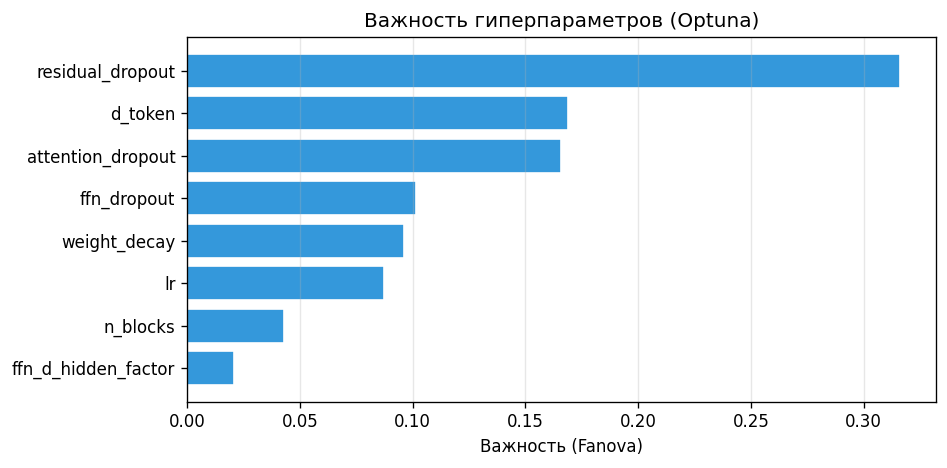

In [20]:
trials_df = study.trials_dataframe()
base_cols  = ['number', 'value']
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
top5 = (
    trials_df[trials_df['state'] == 'COMPLETE']
    .sort_values('value')
    .head(5)[base_cols + param_cols]
    .rename(columns={'number': 'Trial', 'value': 'RMSE (val)'})
    .reset_index(drop=True)
)
print('Top-5 trials:')
display(top5.style.format({'RMSE (val)': '{:.4f}', 'params_lr': '{:.6f}',
                            'params_weight_decay': '{:.7f}',
                            'params_ffn_d_hidden_factor': '{:.2f}'}))

# График важности гиперпараметров
importances = optuna.importance.get_param_importances(study)
imp_series  = pd.Series(importances).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_series.index, imp_series.values, color='#3498db', edgecolor='white')
ax.set_xlabel('Важность (Fanova)')
ax.set_title('Важность гиперпараметров (Optuna)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Эксперимент 3 - FT-Transformer с лучшими гиперпараметрами

In [21]:
bp = study.best_params
ffn_d_hidden_best = int(bp['d_token'] * bp['ffn_d_hidden_factor'])

model_best = build_fttransformer(
    d_token=bp['d_token'],
    n_blocks=bp['n_blocks'],
    attention_dropout=bp['attention_dropout'],
    ffn_d_hidden=ffn_d_hidden_best,
    ffn_dropout=bp['ffn_dropout'],
    residual_dropout=bp['residual_dropout'],
)
n_params_best = sum(p.numel() for p in model_best.parameters() if p.requires_grad)
print(f'Параметров: {n_params_best:,}')

model_best, fit_time_best, history_best = train_model(
    model_best,
    Xtr_num_t, Xtr_cat_t, ytr_t,
    Xvl_num_t, Xvl_cat_t, yvl_t,
    lr=bp['lr'], weight_decay=bp['weight_decay'],
    max_epochs=300, patience=100, batch_size=256, show_progress=True,
)

Параметров: 2,966,435


Training:  57%|█████▋    | 170/300 [01:23<01:03,  2.04epoch/s, loss=0.00050, val_rmse=0.05260, best=0.04583, patience=100/100]

Early stopping at epoch 171, best epoch = 71, best val_rmse = 0.04583



FT-Transformer — Optuna


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0415,0.0330,0.7676,83.48,0.1517
Test,0.0475,0.0380,0.6975,-,0.0295


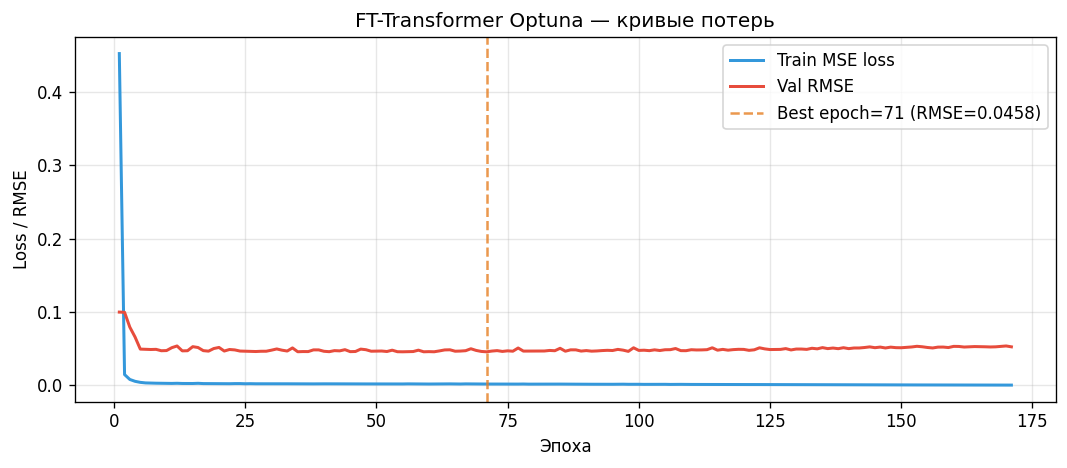

In [22]:
row_best, pred_best = report_metrics('FT-Transformer — Optuna', model_best, fit_time_best)
plot_loss(history_best, 'FT-Transformer Optuna — кривые потерь')

Считаем permutation importance (Optuna-модель, 5 повторений)...


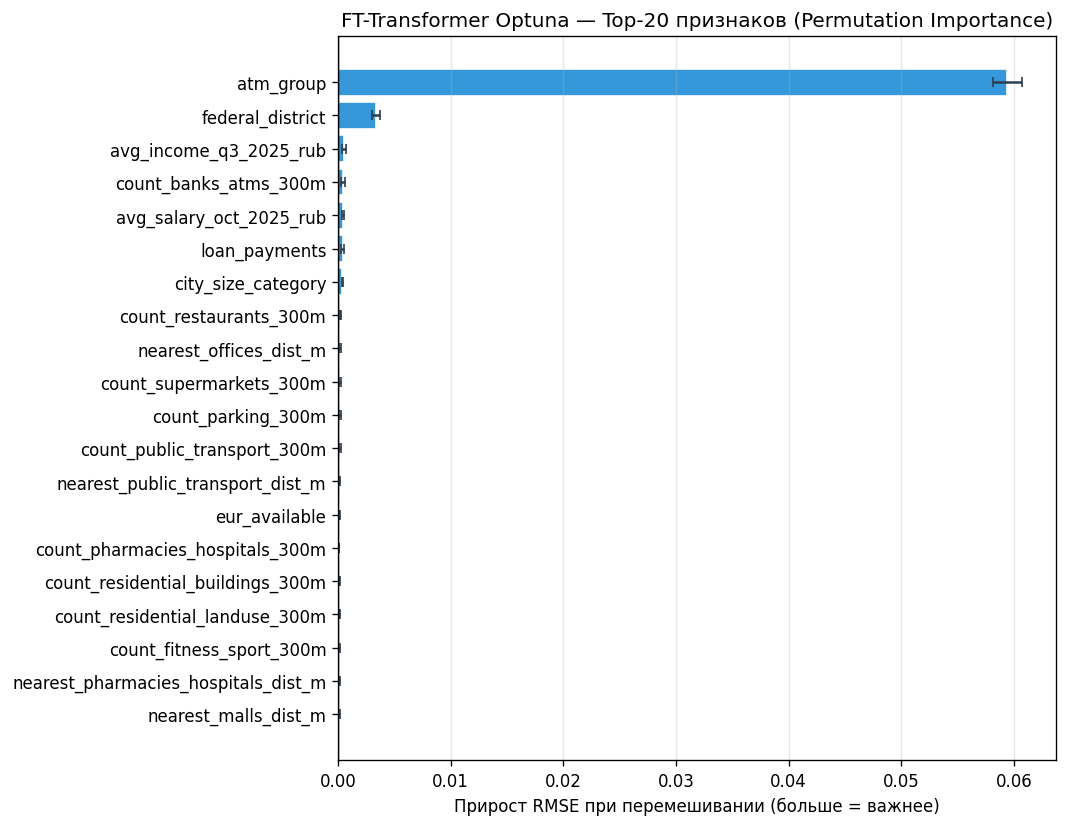

In [23]:
print('Считаем permutation importance (Optuna-модель, 5 повторений)...')
imp_best = permutation_importance_ft(
    model_best,
    Xte_num_t, Xte_cat_t, yte_t,
    CONT_COLS, CATEGORICAL_FEATURES,
    n_repeats=5,
)
plot_permutation_importance(imp_best, 'FT-Transformer Optuna')

Считаем SHAP для 100 тестовых объектов...


100%|██████████| 100/100 [00:51<00:00,  1.96it/s]


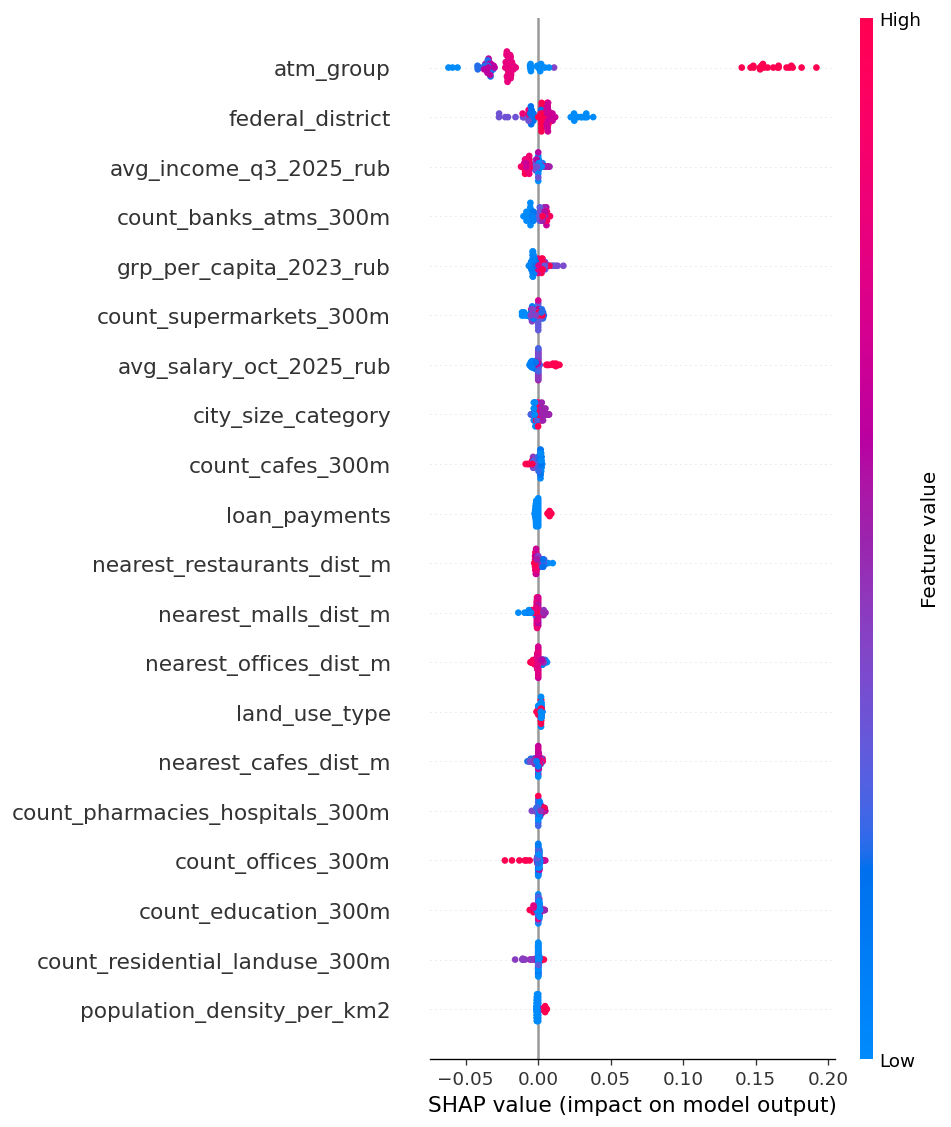

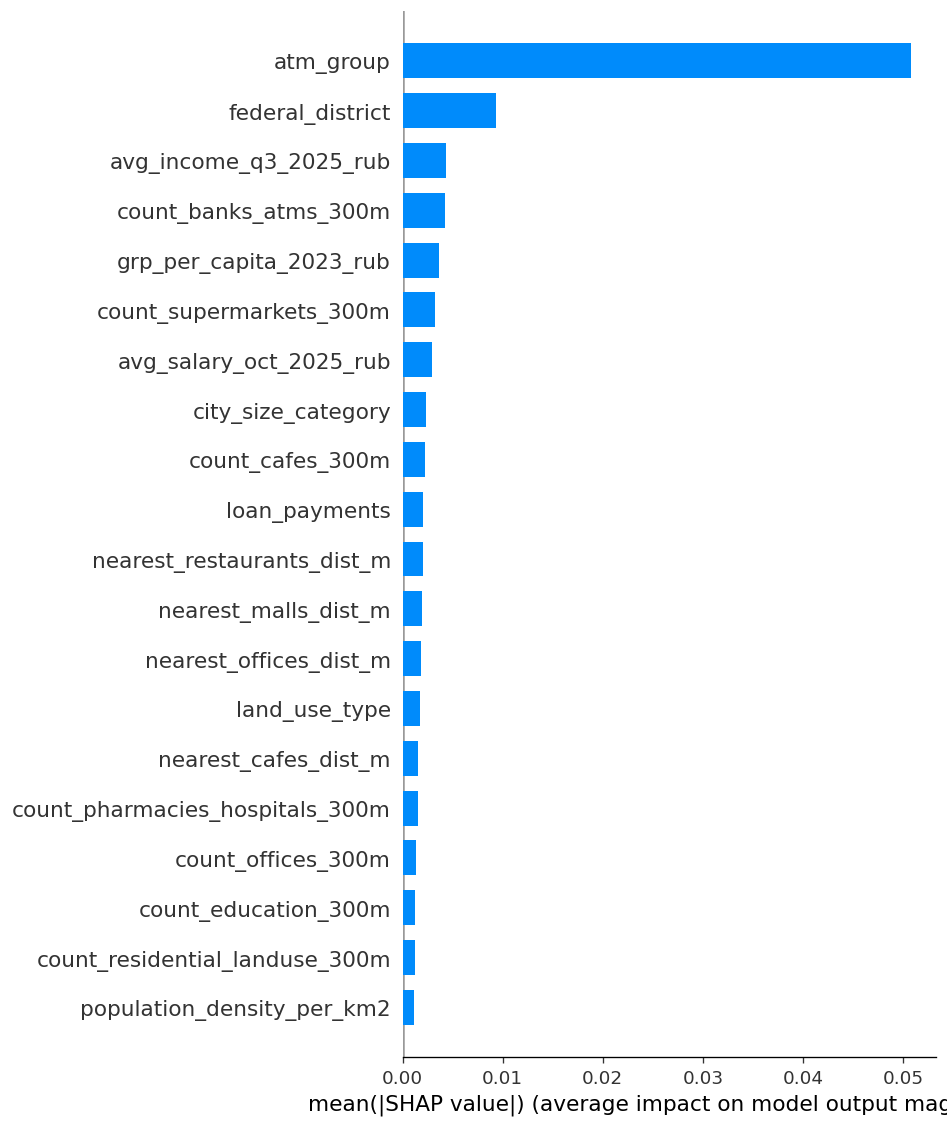

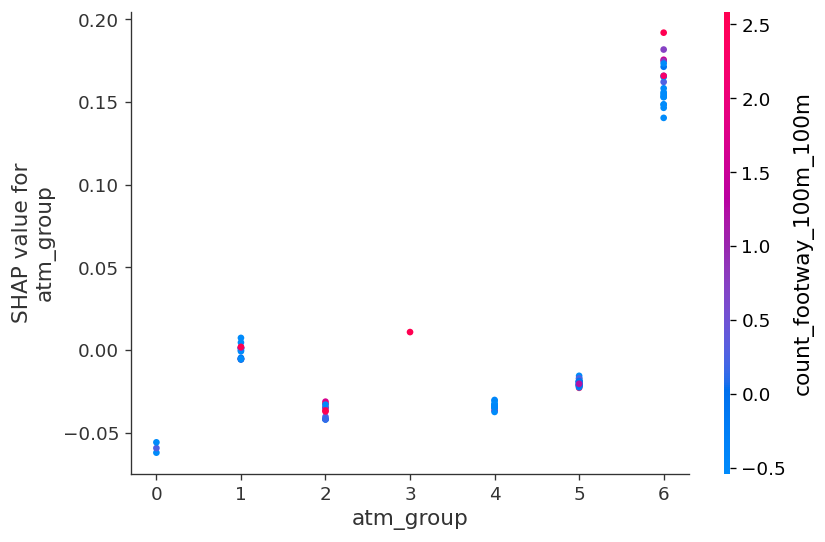

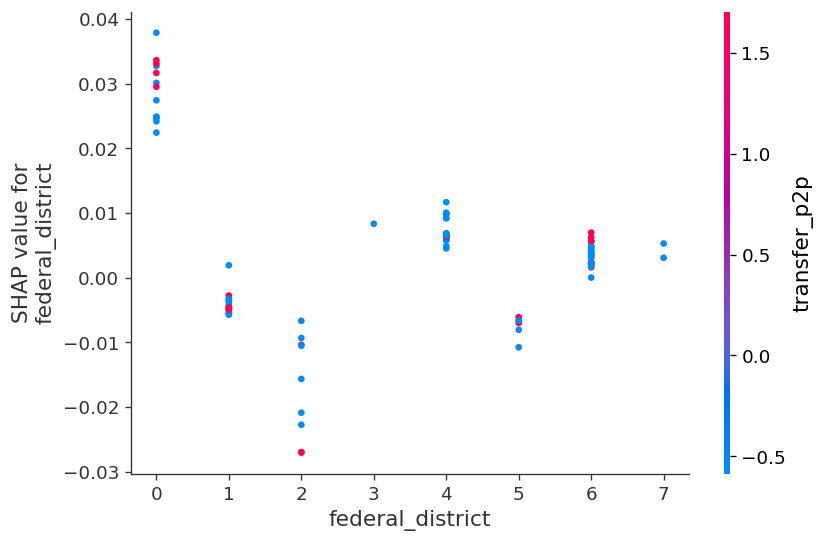

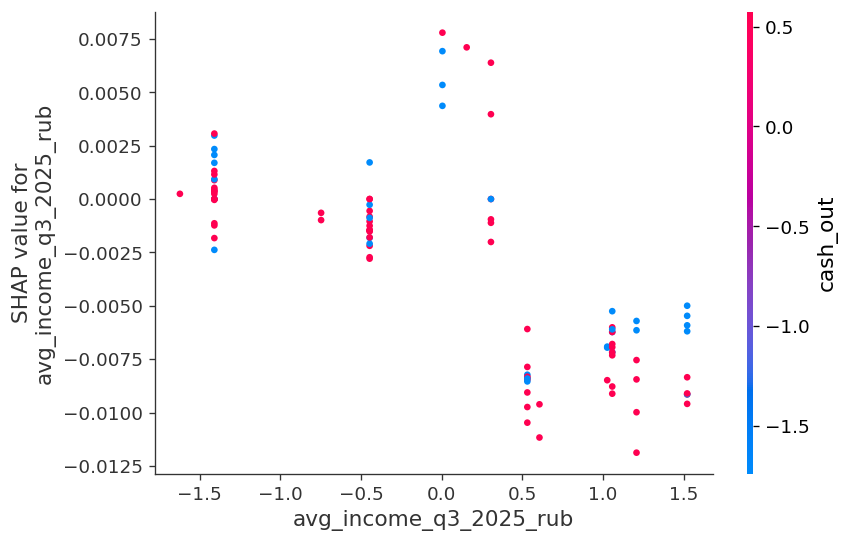

In [27]:
feat_names = CONT_COLS + CATEGORICAL_FEATURES

# Объединяем num + cat в одну numpy-матрицу (SHAP работает с одним входом)
X_test_combined  = np.hstack([X_test_num,  X_test_cat.astype(np.float32)])
X_train_combined = np.hstack([X_train_num, X_train_cat.astype(np.float32)])

def predict_fn(X: np.ndarray) -> np.ndarray:
    """Батчированный предикт для SHAP KernelExplainer."""
    results = []
    batch_size = 512
    for i in range(0, len(X), batch_size):
        X_t   = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(DEVICE)
        x_num = X_t[:, :n_num]
        x_cat = X_t[:, n_num:].long()
        model_best.eval()
        with torch.no_grad():
            results.append(model_best(x_num, x_cat).squeeze(1).cpu().numpy())
    return np.concatenate(results)

# Background: kmeans-сжатие train до 50 точек
background  = shap.kmeans(X_train_combined, 50)
explainer   = shap.KernelExplainer(predict_fn, background)

N_EXPLAIN   = 100   # объектов для объяснения
N_SAMPLES   = 300   # coalition samples (2*n_feat+2048 по умолчанию — слишком медленно)

print(f'Считаем SHAP для {N_EXPLAIN} тестовых объектов...')
shap_values = explainer.shap_values(
    X_test_combined[:N_EXPLAIN], nsamples=N_SAMPLES, l1_reg='aic'
)

# ── Графики ──────────────────────────────────────────────────────────────────

# 1. Bee-swarm: как каждый признак влияет на предсказание
shap.summary_plot(shap_values, X_test_combined[:N_EXPLAIN],
                  feature_names=feat_names)

# 2. Bar chart: mean |SHAP| — глобальная важность
shap.summary_plot(shap_values, X_test_combined[:N_EXPLAIN],
                  feature_names=feat_names, plot_type='bar')

# 3. Dependence plot для топ-3 признаков
top3 = np.abs(shap_values).mean(axis=0).argsort()[::-1][:3]
for idx in top3:
    shap.dependence_plot(idx, shap_values, X_test_combined[:N_EXPLAIN],
                         feature_names=feat_names)


## 9. Сохранение лучшей модели

In [ ]:
# Финальная модель — переобучаем на train+val с оптимальным числом эпох
best_epoch = int(np.argmin(history_best['val_rmse'])) + 1
print(f'Переобучаем на X_trainval ({len(Xtv_num_t)} объектов), {best_epoch} эпох...')

model_final = build_fttransformer(
    d_token=bp['d_token'],
    n_blocks=bp['n_blocks'],
    attention_dropout=bp['attention_dropout'],
    ffn_d_hidden=ffn_d_hidden_best,
    ffn_dropout=bp['ffn_dropout'],
    residual_dropout=bp.get('residual_dropout', 0.0),
)
model_final, _, _ = train_model(
    model_final,
    Xtv_num_t, Xtv_cat_t, ytv_t,
    Xtv_num_t, Xtv_cat_t, ytv_t,  # val = train (нет утечки — обучаем фиксированное число эпох)
    lr=bp['lr'], weight_decay=bp['weight_decay'],
    max_epochs=best_epoch, patience=best_epoch + 1,
    batch_size=256,
)

save_path = MODELS_DIR / 'fttransformer_best.pt'
torch.save({
    'model_state_dict':  model_final.state_dict(),
    'hyperparams':       bp,
    'ffn_d_hidden':      ffn_d_hidden_best,
    'n_num':             n_num,
    'cat_cardinalities': cat_cardinalities,
    'feat_names':        CONT_COLS + CATEGORICAL_FEATURES,
}, save_path)
print(f'Модель сохранена: {save_path}')

## 10. Итоговая таблица экспериментов

In [29]:
bp = study.best_params

experiments = pd.DataFrame([
    {
        'Эксперимент': 'FT-Transformer Базовый',
        'd_token': 192, 'n_blocks': 3, 'n_heads': 8,
        'lr': 1e-4, 'weight_decay': 1e-5,
        'RMSE': row_base['RMSE'], 'MAE': row_base['MAE'], 'R\u00b2': row_base['R\u00b2'],
        'Время обучения, с': row_base['Fit time, s'],
    },
    {
        'Эксперимент': 'FT-Transformer + Optuna',
        'd_token': bp['d_token'], 'n_blocks': bp['n_blocks'],
        'lr': round(bp['lr'], 6), 'weight_decay': round(bp['weight_decay'], 7),
        'RMSE': row_best['RMSE'], 'MAE': row_best['MAE'], 'R\u00b2': row_best['R\u00b2'],
        'Время обучения, с': row_best['Fit time, s'],
    },
]).set_index('Эксперимент')

display(
    experiments.style
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R\u00b2'])
    .format({
        'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R\u00b2': '{:.4f}',
        'lr': '{:.6f}', 'weight_decay': '{:.7f}',
        'Время обучения, с': '{:.1f}',
    })
)

,d_token,n_blocks,n_heads,lr,weight_decay,RMSE,MAE,R²,"Время обучения, с"
Эксперимент,,,,,,,,,
FT-Transformer Базовый,192,3,8.000000,0.000100,0.0000100,0.0475,0.0379,0.6973,21.8
FT-Transformer + Optuna,256,3,nan,0.000234,0.0001047,0.0475,0.0380,0.6975,83.5


## 11. Выводы

Главным признаком для модели оказался `atm_group`, что наблюдалось ранее и у других моделей, разрыв между важностью этого признака и следующих очень большой. 

### FT-Transformer vs весь ряд моделей

| Модель | RMSE (test) | R² (test) |
|--------|-------------|----------|
| LinearRegression (лучшая) | 0.0596 | 0.5235 |
| Decision Tree (Optuna) | 0.0484 | 0.6858 |
| TabNet базовый | 0.0500 | 0.6647 |
| TabNet + Optuna | 0.0491 | 0.6766 |
| **FT-Transformer базовый** | **0.0475** | **0.6973** |
| **FT-Transformer + Optuna** | **0.0475** | **0.6975** |
| CatBoost (Optuna) | 0.0453 | 0.7249 |
| XGBoost (Baseline) | 0.0451 | 0.7276 |
| LightGBM (Optuna) | 0.0448 | 0.7307 |
| Random Forest (Optuna) | 0.0444 | 0.7359 |

Baseline и Optuna вышли на одинаковый RMSE (0.0475) — параметры по умолчанию из статьи уже близки к оптимуму для этого датасета. Optuna чуть лучше по R² (0.6975 vs 0.6973), однако разница несущественна.

**Почему DL-модели уступают градиентному бустингу на этом датасете:**
- 6 200 строк — небольшая выборка; трансформеры раскрываются при ~50k+ примерах
- Много бинарных и счётных признаков, для которых деревья являются «родным» форматом
- Отсутствие зависимостей с длинным «плечом» (нет текста, временных рядов, иерархий)

**Главное преимущество FT-Transformer** — масштабируемость и потенциал к предобучению: при наличии большего объёма табличных данных (или возможности self-supervised pretraining) трансформерные архитектуры способны превзойти ансамблевые методы.